<a href="https://colab.research.google.com/github/pandeynivedita7/codingal/blob/main/machinelearninglabpractical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q1: 36
Q2: 0.0
Q3: False
Q4: 0
Q5: 0
Q6: 12


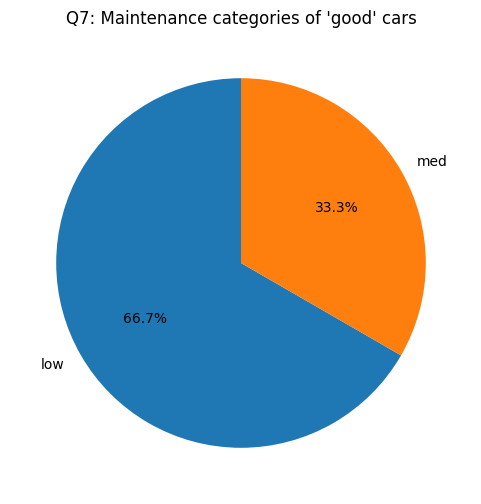

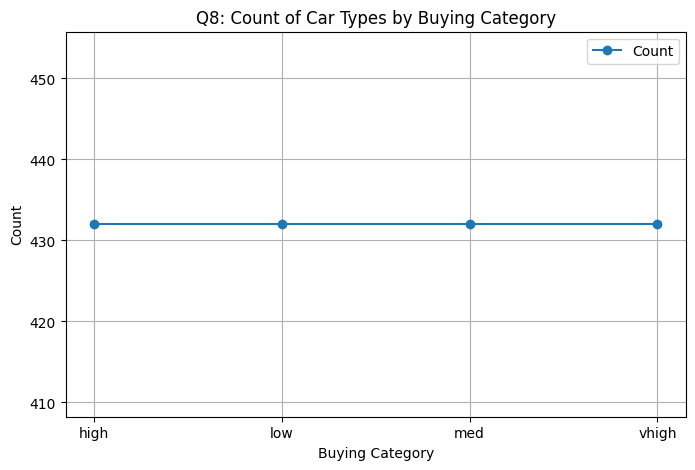

/tmp/ipython-input-13-3688889244.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='persons', palette='pastel')


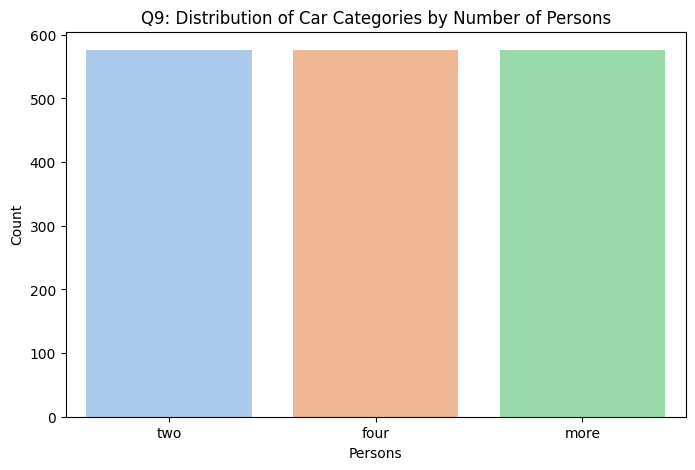

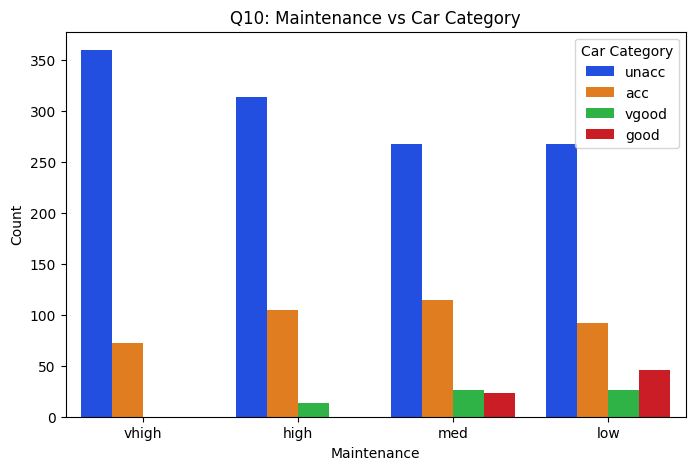

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('cars_dataset.csv')
#1.	Find the count of the entries having “vhigh” in buying and “5more” in doors columns, that provide low safety
q1 = df[(df['buying'] == 'vhigh') & (df['doors'] == '5more') & (df['safety'] == 'low')].shape[0]
print("Q1:", q1)
#Q1: 36
#2.	Find the proportion of small lug_boot that allow four persons in the entire dataset.
q2 = df[(df['lug_boot'] == 'small') & (df['persons'] == '4')].shape[0] / df.shape[0]
print("Q2:", q2)
#Q2: 0.0
#3.	Is the dataset uniformly distributed across classes? Return True or False.
q3 = df['car'].value_counts().nunique() == 1
print("Q3:", q3)
#Q3: False
#4.How many unacc classes have two or three doors?
q4 = df[(df['car'] == 'unacc') & (df['doors'].isin(['2', '3']))].shape[0]
print("Q4:", q4)
#Q4: 0
#5.	Find the total four doored car with high safety that has low maintenance
q5 = df[(df['doors'] == '4') & (df['safety'] == 'high') & (df['maint'] == 'low')].shape[0]
print("Q5:", q5)
#Q5: 0
#6.	Find the total cars that is ‘med’ in buying, maintenance, lug_boot and safety,
q6 = df[(df['buying'] == 'med') & (df['maint'] == 'med') &
        (df['lug_boot'] == 'med') & (df['safety'] == 'med')].shape[0]
print("Q6:", q6)
#Q6: 12
#7.	Show a pie plot for the maintenance categories of ‘good’ cars.
plt.figure(figsize=(6, 6))
df[df['car'] == 'good']['maint'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title("Q7: Maintenance categories of 'good' cars")
plt.ylabel('')
plt.show()
#8.1.	Draw a line plot taking the types of buying in x-axis and its count in the y-axis. Show the legend, title and label accordingly.
buying_counts = df['buying'].value_counts().sort_index()
plt.figure(figsize=(8, 5))
plt.plot(buying_counts.index, buying_counts.values, marker='o')
plt.title('Q8: Count of Car Types by Buying Category')
plt.xlabel('Buying Category')
plt.ylabel('Count')
plt.legend(['Count'])
plt.grid(True)
plt.show()
#9.1.	Plot a seaborn’s bar chart to represent the categories in ‘persons’.
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='persons', palette='pastel')
plt.title('Q9: Distribution of Car Categories by Number of Persons')
plt.xlabel('Persons')
plt.ylabel('Count')
plt.show()
#10.	Show the categories in ‘maint’ column with hue of car category.
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='maint', hue='car', palette='bright')
plt.title('Q10: Maintenance vs Car Category')
plt.xlabel('Maintenance')
plt.ylabel('Count')
plt.legend(title='Car Category')
plt.show()



In [15]:
#part 2
#Using the same dataset, perform the following:			(2x5=10 marks)
#Any two classification algorithms and compare their performances. Use 5-fold cross validation.

import pandas as pd
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
df = pd.read_csv('cars_dataset.csv')
le = LabelEncoder()
df_encoded = df.apply(le.fit_transform)
X = df_encoded.drop(columns=['car'])
y = df_encoded['car']
# Classifier 1: Naive Bayes
nb = GaussianNB()
cv1 = cross_val_score(nb, X, y, cv=KFold(n_splits=5), scoring='accuracy')
# Classifier 2: Decision Tree
dt = DecisionTreeClassifier(random_state=42)
cv2 = cross_val_score(dt, X, y, cv=KFold(n_splits=5), scoring='accuracy')
print("Classification (5-Fold CV) Results:")
print(f"Naive Bayes Accuracy: {cv1.mean():.4f}")
print(f"Decision Tree Accuracy: {cv2.mean():.4f}")
X_cluster = df_encoded.drop(columns=['car'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
kmeans_score = silhouette_score(X_scaled, kmeans_labels)
agglo = AgglomerativeClustering(n_clusters=4)
agglo_labels = agglo.fit_predict(X_scaled)
agglo_score = silhouette_score(X_scaled, agglo_labels)
print("\nClustering Results (Silhouette Scores):")
print(f"KMeans Silhouette Score: {kmeans_score:.4f}")
print(f"Agglomerative Clustering Silhouette Score: {agglo_score:.4f}")
#Classification (5-Fold CV) Results:
#Naive Bayes Accuracy: 0.6064
#Decision Tree Accuracy: 0.9473
#Clustering Results (Silhouette Scores):
#KMeans Silhouette Score: 0.1223
#Agglomerative Clustering Silhouette Score: 0.0612


Classification (5-Fold CV) Results:
Naive Bayes Accuracy: 0.6064
Decision Tree Accuracy: 0.9473

Clustering Results (Silhouette Scores):
KMeans Silhouette Score: 0.1223
Agglomerative Clustering Silhouette Score: 0.0612


In [17]:
#Part2
#Clustering Without Label Column (car)
#2.	Exclude the label (last column) from the dataset and work on any two clustering algorithms.
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
df = pd.read_csv('cars_dataset.csv')
le = LabelEncoder()
df_encoded = df.apply(le.fit_transform)
X = df_encoded.drop(columns=['car'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
print(f"KMeans Clustering Silhouette Score: {kmeans_silhouette:.4f}")
agglo = AgglomerativeClustering(n_clusters=4)
agglo_labels = agglo.fit_predict(X_scaled)
agglo_silhouette = silhouette_score(X_scaled, agglo_labels)
print(f"Agglomerative Clustering Silhouette Score: {agglo_silhouette:.4f}")


KMeans Clustering Silhouette Score: 0.1223
Agglomerative Clustering Silhouette Score: 0.0612
